In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [9]:
df = pd.read_csv("Healthcare_Patient_Dataset.csv")

print("Dataset Loaded Successfully!\n")

print("First 5 Rows:")
display(df.head())

Dataset Loaded Successfully!

First 5 Rows:


,Patient_ID,Age,Gender,Height,Weight,Blood_Pressure,Blood_Sugar,Diagnosis
0,P001,25,Male,172,68.0,118.0,92.0,Healthy
1,P002,42,Female,160,74.0,135.0,145.0,Diabetes
2,P003,36,Male,178,82.0,128.0,98.0,Healthy
3,P004,58,Female,155,69.0,150.0,180.0,Hypertension
4,P005,47,Male,169,85.0,142.0,165.0,Diabetes


In [10]:
print("\nDataset Information:")
df.info()

print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient_ID      43 non-null     str    
 1   Age             43 non-null     int64  
 2   Gender          42 non-null     str    
 3   Height          43 non-null     int64  
 4   Weight          42 non-null     float64
 5   Blood_Pressure  42 non-null     float64
 6   Blood_Sugar     42 non-null     float64
 7   Diagnosis       43 non-null     str    
dtypes: float64(3), int64(2), str(3)
memory usage: 2.3 KB

Missing Values in Each Column:
Patient_ID        0
Age               0
Gender            1
Height            0
Weight            1
Blood_Pressure    1
Blood_Sugar       1
Diagnosis         0
dtype: int64


In [11]:
numerical_columns = df.select_dtypes(include=['number']).columns

# Fill missing numerical values with median
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())


# Identify categorical/string columns
categorical_columns = df.select_dtypes(include=['str']).columns

# Fill missing categorical values with mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


print("\nMissing Values After Imputation:")
print(df.isnull().sum())


Missing Values After Imputation:
Patient_ID        0
Age               0
Gender            0
Height            0
Weight            0
Blood_Pressure    0
Blood_Sugar       0
Diagnosis         0
dtype: int64


In [12]:
gender_encoder = LabelEncoder()
diagnosis_encoder = LabelEncoder()

df["Gender"] = gender_encoder.fit_transform(df["Gender"])
df["Diagnosis"] = diagnosis_encoder.fit_transform(df["Diagnosis"])


print("\nDataset After Label Encoding:")
display(df.head())


Dataset After Label Encoding:


,Patient_ID,Age,Gender,Height,Weight,Blood_Pressure,Blood_Sugar,Diagnosis
0,P001,25,1,172,68.0,118.0,92.0,1
1,P002,42,0,160,74.0,135.0,145.0,0
2,P003,36,1,178,82.0,128.0,98.0,1
3,P004,58,0,155,69.0,150.0,180.0,2
4,P005,47,1,169,85.0,142.0,165.0,0


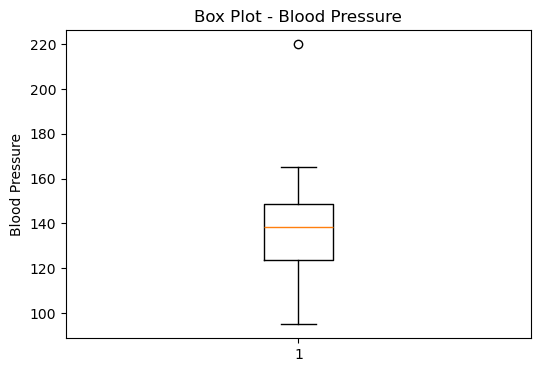

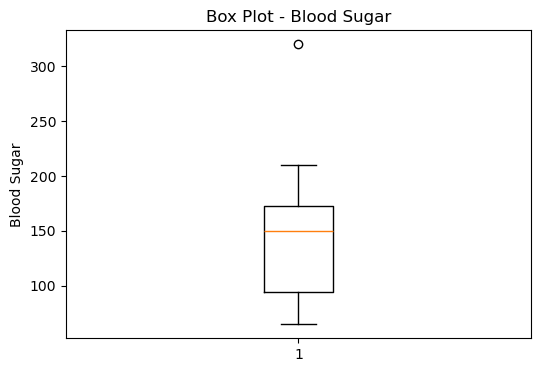

In [13]:
# Box Plot - Blood Pressure
plt.figure(figsize=(6, 4))
plt.boxplot(df["Blood_Pressure"])
plt.title("Box Plot - Blood Pressure")
plt.ylabel("Blood Pressure")
plt.show()


# Box Plot - Blood Sugar
plt.figure(figsize=(6, 4))
plt.boxplot(df["Blood_Sugar"])
plt.title("Box Plot - Blood Sugar")
plt.ylabel("Blood Sugar")
plt.show()

In [14]:
scaler = MinMaxScaler()

columns_to_scale = [
    "Age",
    "Height",
    "Weight",
    "Blood_Pressure",
    "Blood_Sugar"
]

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)


print("\nDataset After Min-Max Normalization:")
display(df.head())



Dataset After Min-Max Normalization:


,Patient_ID,Age,Gender,Height,Weight,Blood_Pressure,Blood_Sugar,Diagnosis
0,P001,0.062500,1,0.666667,0.356164,0.184,0.105882,1
1,P002,0.416667,0,0.222222,0.438356,0.320,0.313725,0
2,P003,0.291667,1,0.888889,0.547945,0.264,0.129412,1
3,P004,0.750000,0,0.037037,0.369863,0.440,0.450980,2
4,P005,0.520833,1,0.555556,0.589041,0.376,0.392157,0



Correlation Matrix:


,Age,Gender,Height,Weight,Blood_Pressure,Blood_Sugar,Diagnosis
Age,1.000000,0.036502,-0.187900,0.609872,0.909324,0.928787,0.376800
Gender,0.036502,1.000000,0.885913,0.722732,0.161098,0.124343,-0.236083
Height,-0.187900,0.885913,1.000000,0.575172,-0.047688,-0.095353,-0.319282
Weight,0.609872,0.722732,0.575172,1.000000,0.738264,0.702445,-0.030383
Blood_Pressure,0.909324,0.161098,-0.047688,0.738264,1.000000,0.969827,0.338999
Blood_Sugar,0.928787,0.124343,-0.095353,0.702445,0.969827,1.000000,0.239569
Diagnosis,0.376800,-0.236083,-0.319282,-0.030383,0.338999,0.239569,1.000000


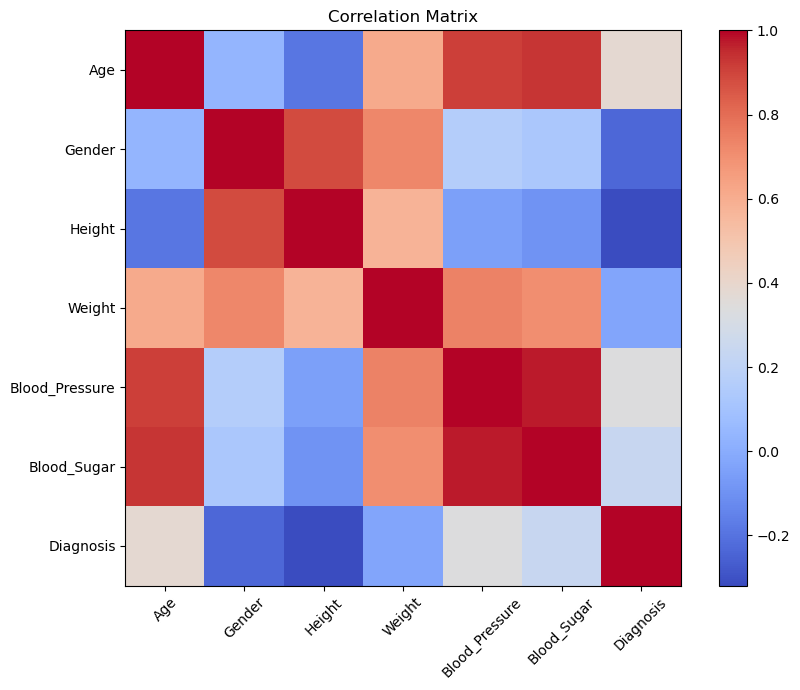

In [15]:
correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
display(correlation_matrix)


# Display Correlation Matrix as a Plot
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


In [16]:
df.to_csv(
    "healthcare_processed.csv",
    index=False
)

print("\nProcessed dataset saved successfully as 'healthcare_processed.csv'!")


Processed dataset saved successfully as 'healthcare_processed.csv'!
